<a href="https://colab.research.google.com/github/d-toups/workout-data-analysis/blob/main/workout_data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workout Data Analysis: Gender & Age Differences in Fitness Preferences & Calorie Burn

**Objective**:  
Explore how workout preferences and calorie expenditure differ by gender and age group using exploratory data analysis.

**Business Value**:  
These insights can help fitness apps, gyms, and wellness platforms create more targeted programs and recommendations.

## 1. Project Overview

## Project Goal
Analyze workout preferences and calorie expenditure patterns across different genders and age groups using exploratory data analysis.

**Business Context**:  
Understanding demographic differences in fitness behavior can help gyms, fitness apps, and health companies create more personalized programs and marketing strategies.

## Key Questions
- What workout types are most popular among different genders?
- How does calorie burn vary by age group and workout type?
- Are there noticeable differences in behavior between males and females?

## Tech Stack
- Python (pandas, seaborn, matplotlib)
- Jupyter Notebook

## 2. Data Loading and Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

################### Function Definition #######################################

""" Load Dataset ***********************************************************
Purpose: Reads .csv dataset into pandas dataframe

Inputs: filepath - file to be read in

Outputs: df - dataset in dataframe format

----------------------------------------------------------------------------"""

def load_dataset(filepath):
    # Use specified columns to read in Age, Gender, Workout Type, Workout
    # Duration, and Calories Burned
    df = pd.read_csv(filepath, usecols=[2, 3, 5, 6, 7])
    return df

## 3. Data Cleaning

In [2]:
""" Clean Dataset *************************************************************
Purpose: Clean raw dataset, create Calories Per Minute feature

Inputs: df - dataset consisting workout metrics

Outputs: df - cleaned dataset to be analyzed
        df_male - cleaned dataset to be analyzed consisting of male data
        df_female - cleaned dataset to be analyzed consisting of female data
        df_adults - cleaned dataset consisting of both genders together in one
        dataframe. Needed for one of the visualizations generated by
        create_visualizations.

----------------------------------------------------------------------------"""

def clean_dataset(df):
    # Check for and remove missing values
    print('\nCheck null values:\n', df.isna().sum())
    df = df.dropna()

    # Clean strings to title format
    df.columns = df.columns.str.title()
    df.columns = df.columns.str.replace("_", ' ')
    df['Gender'] = df.Gender.str.title()

    # We want to keep the HIIT elements uppercase, all others title case
    df['Workout Type'] = df['Workout Type'].apply( lambda x: x.upper() if \
                                                  str(x).isupper() else \
                                                  x.title())

    # Add calories per minute feature
    df['Calories Per Minute'] = df['Calories Burned'] / df[\
                                                    'Workout Duration Minutes']
    # Filter out 'Other' values for gender
    df = df[df['Gender'] != 'Other']

    # Bin ages into age groups
    age_bins = [17, 34, 64, 200]
    age_groups = ['Young Adult', 'Adult', 'Senior']
    df['Age Group'] = pd.cut(df['Age'], bins = age_bins, labels=age_groups)

    # Categorize Workout Type for later analysis
    df['Quantified Workout Type'] = df['Workout Type'].astype('category')

    # Separate by gender, retain only 'Male' and 'Female' data
    df_male = df[df['Gender'] == 'Male']
    print('\nMale samples\n', df_male['Gender'].count())
    df_female = df[df['Gender'] == 'Female']
    print('\nFemale samples\n', df_female['Gender'].count())

    # Check for consistency in categorical features
    print('\nGender values: ', df_male['Gender'].unique(), df_female[\
                                                            'Gender'].unique())
    print('\nWorkout Type values: ', df['Workout Type'].unique())
    df_adults = df[df['Age Group'] != 'Seniors']
    return df, df_male, df_female, df_adults

## Specific cleaning actions taken were:
- keep "HIIT" capitalized by using a lambda function
- add Calories Per Minute to aid further analysis
- filter out ambiguous "Other" entries for gender
- bin ages into age groups for cohort analysis
- categorize Workout Type
- confirm data cleaning by checking unique values of gender and workout type

## 4. Exploratory Data Analysis

In [3]:
""" Explore Dataset ***********************************************************
Purpose: Generate statistics from the dataset as well as box and density plots
        to begin identifying trends.

Inputs: df - dataset consisting of one gender's exercise metrics
        gender - the gender currently being analyzed
Outputs: Initial visualizations of the dataset.

----------------------------------------------------------------------------"""

def explore_dataset(df, gender):

    # Print summary information
    print('\nSamples By Age:\n', df['Age Group'].value_counts())

    # Display summary statistics for all columns
    pd.set_option('display.max_columns', None)
    print('\nSummary Statistics\n', df.describe())
    pd.reset_option('display.max_columns')

    # View age group statistics:
    cols = ['Workout Duration Minutes', 'Calories Burned', \
            'Calories Per Minute']

    for col in cols:

        # Quartile boxplots
        ax = df.boxplot(column=col, by = 'Age Group')
        ax.get_figure().suptitle('')
        plt.title(f'{gender} {col} Quartiles')
        plt.ylabel(f'{col}')
        plt.show()

        # Plot densities
        print(f'\n{gender} {col} Age Group Statistics:\n', \
              df.groupby('Age Group', observed=True)[col].agg(['mean', 'std',\
                                                                'var']) )
        ax = df.groupby('Age Group', observed=True)[col].plot(\
                kind='density', title=f'{gender} {col} Density', legend=True)
        plt.xlabel(f'{col}')
        plt.tight_layout()
        plt.show()

    # Print statistics for workout type preferences (visualized in
    # create_visualizations function)
    print(f'\n{gender} Workout Type Preference (%):\n', df.groupby('Age Group')\
          ['Workout Type'].value_counts(normalize=True)*100, '\n')

    return

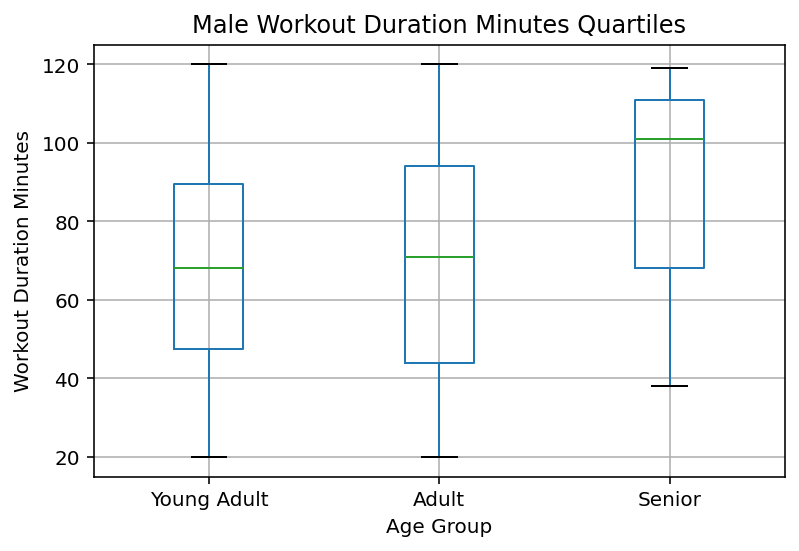

In the boxplot above, we observe that senior males workout for substantially longer periods than young adults and adults, averaging over 100 minutes per workout. Young adults and adults are nearly identical in workout duration average per workout and maxima / minima.

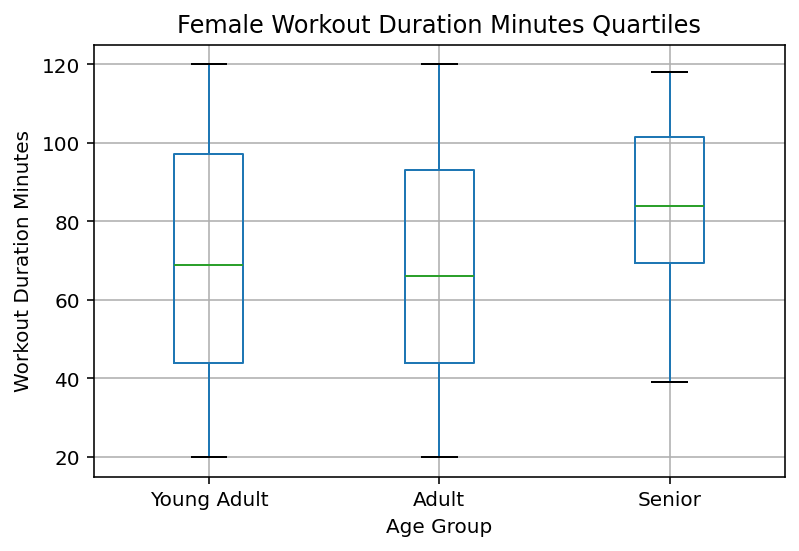

Similar to males, female seniors also average longer workouts than adult and young adult female seniors.

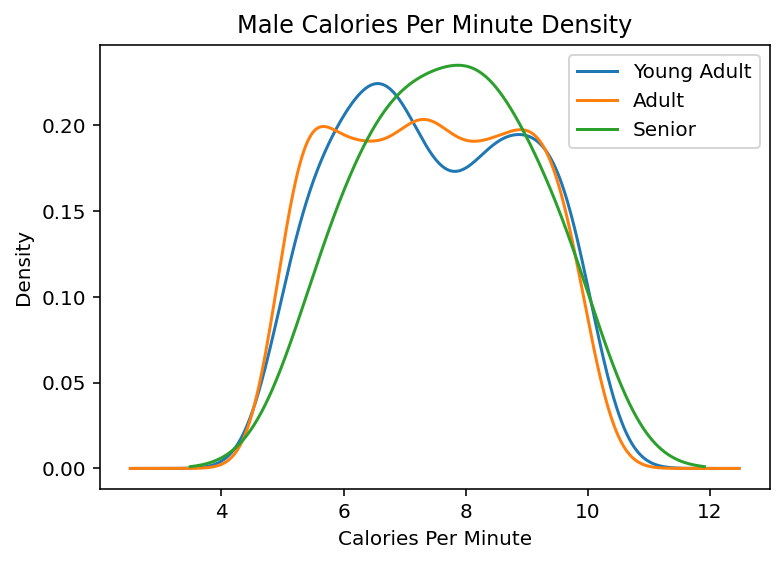

CPM density among young adult males is seemingly distributed between higher intensity exercise yielding higher CPM as well as lower intensity exercise such as cardio with a lower CPM. Adults gravitate to three CPM areas, presumably due to exercise types of low, medium, and high intensity. Seniors see a more even distribution as they likely choose lower intensity exercise performed at varying intensity levels unique to each individual's fitness and abilities.

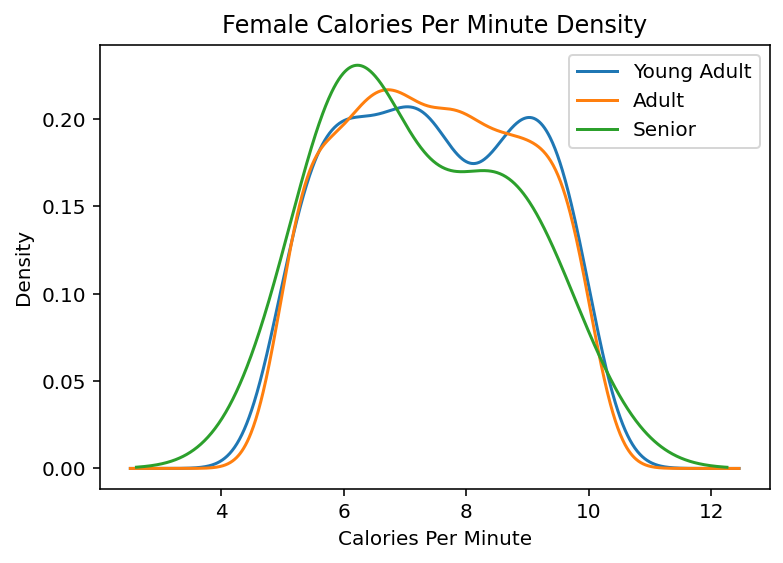

Female CPM density is similar to males, with some notable differences. Young adult females see a wider CPM range in the low to mid-intensity range, and a smaller concentration at the higher intensity CPM range. Adult females are similar to males with a bit fewer exercising at high intensity. Female seniors are less evenly distributed than males, with a clear preference for low intensity exercise with a notable number choosing mid-level intensity exercise.

## 5. Key Visualizations and Insights

In [4]:
""" Create Visualizations *****************************************************
Purpose: Generate visualizations to illustrate insights from the dataset.

Inputs: df - dataframe assumed to be specific to gender
        gender - which gender is currently being analyzed (needed for plotting)
        df_a - dataframe consisting of both genders in the same dataframe

Outputs: Generates bar graphs showing workout type preferences as well as
        stacked density plots for calories burned per minute by age group and
        by workout type.

----------------------------------------------------------------------------"""

def create_visualizations(df, gender, df_a):
    # Normalize value_counts and generate percentage
    group = 100 * df.groupby('Age Group', observed=True)['Workout Type'].\
        value_counts(normalize=True).unstack()

    # Streamline color palettes for plotting
    colors = sns.color_palette("Set2", n_colors=5)

    ax = group.plot(kind='bar', \
         title=f'{gender} Workout Type Preference Analysis', legend=True, \
             color=colors)
    plt.ylabel('Percent of Total Workouts')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(0.95, -0.01), loc='lower right')
    plt.tight_layout()
    plt.show()

    # Plot distribution of Calories per minute for Age Groups
    p = sns.displot(
        data=df,
        x='Calories Per Minute',
        hue='Age Group',
        multiple='stack',
        kind='kde',
        palette='Set2',
        edgecolor='white'
    )
    p.figure.suptitle(f'{gender} Calories Per Minute Density')
    plt.tight_layout()
    plt.show()

    # Plot distribution of Calories per minute
    p = sns.displot(
        data=df,
        x='Calories Per Minute',
        hue='Quantified Workout Type',
        multiple='stack',
        kind='kde',
        palette='Set2',
        edgecolor='white'
    )
    p.figure.suptitle(f'{gender} Calories Per Minute Density')
    plt.tight_layout()
    plt.show()

    return

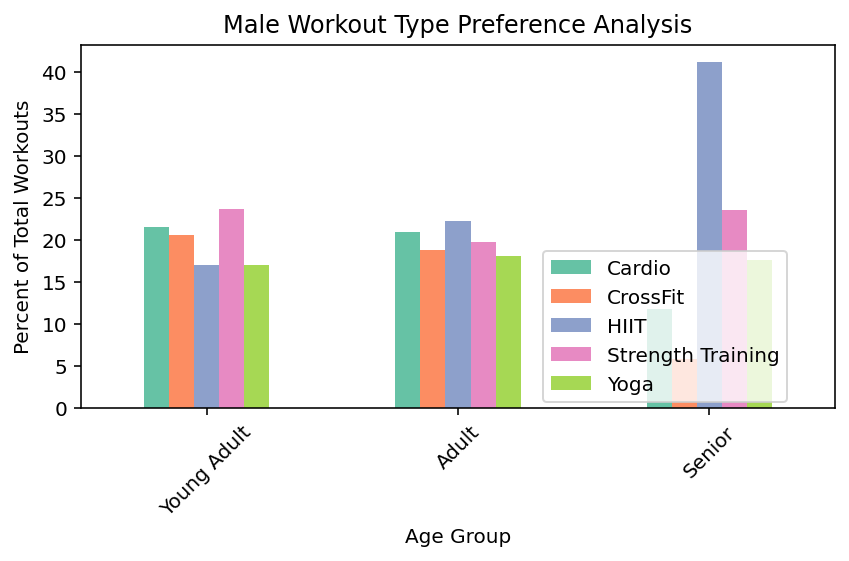

Above, we can see that adult and young adult males have a slightly similar preference for cardio. Each age group has specific preferences otherwise, with young adults unsurprisingly favoring strength training while adults most favoring HIIT. Seniors surprisingly favor HIIT. It is worth noting here that the number of seniors in the dataset is small (15 total) and all are the same age (65), so this is likely not an accurate representation of all seniors.

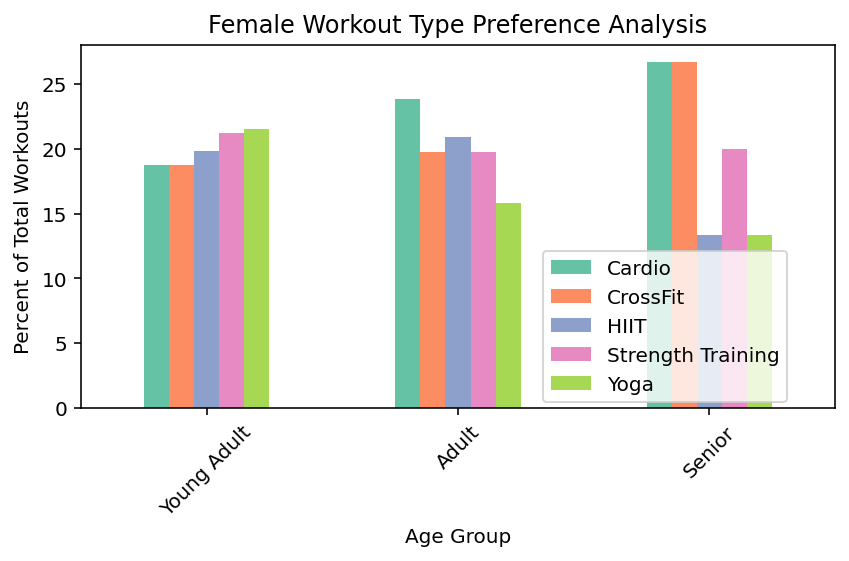

Here, we see senior and adult females prefer cardio, with young adults most performing yoga and strength training. Adult females seem to prefer yoga least, which I found surprising.

Next, we take a look at more density plots.

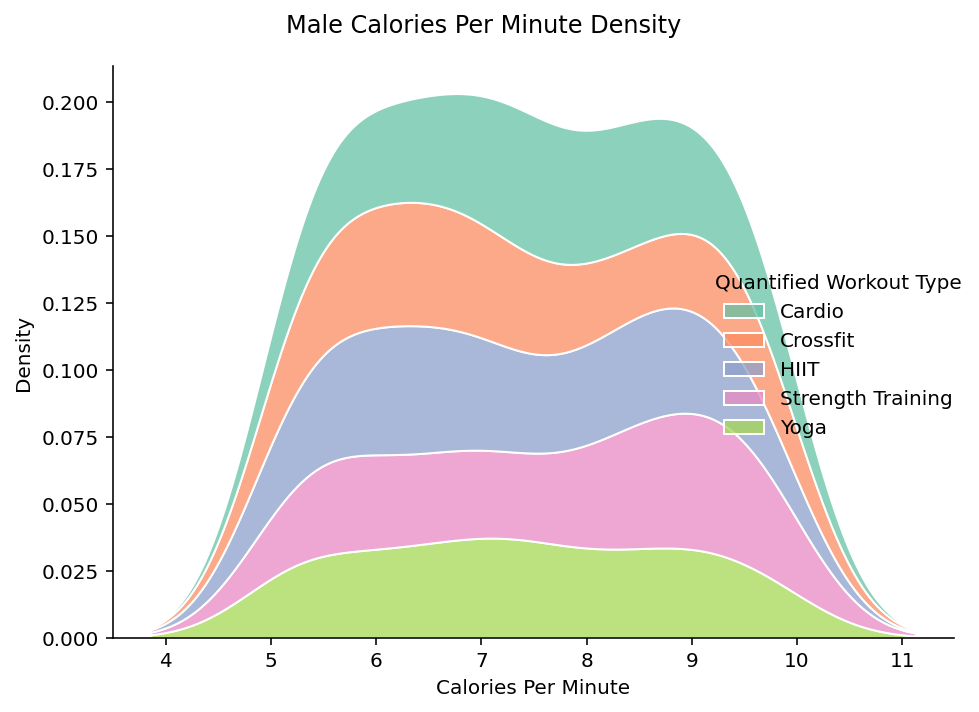

From this plot, we see notably consistent differences in Calories Per Minute (CPM) density from 5 to 10 CPM. The trough of roughly 7.5-8.5 CPM is possibly due to workouts typically being short and intense (the high peak near 9CPM), or longer but less taxing (easy cardio, strength training, etc).

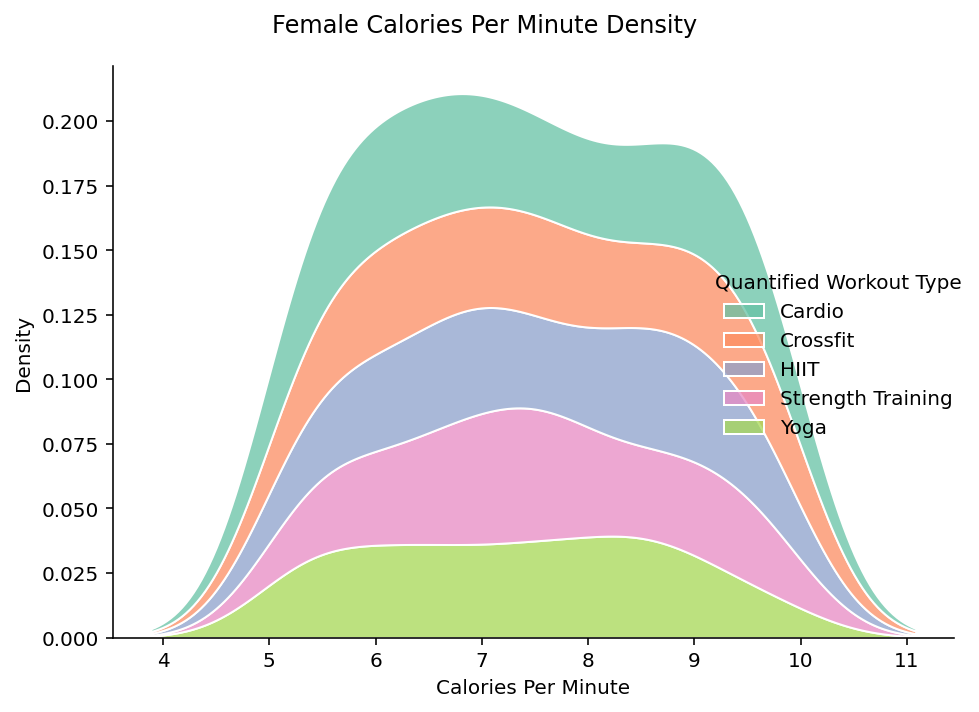

We see similarities and differences between males and females as we analyze the female plot. Notably, females training strength participate in markedly less intense sessions than males as the peak near 7 CPM illustrates. Further, it seems that females across all workout types participate in less high-intensity (or high CPM) workouts. However, the left peak in each distribution is markedly higher in CPM than the left peak for males. This means, while females may not train to high-intensity as males do, they push harder intensities in their longer duration workouts.

## 6. Statistical Analysis

In [5]:
""" Stats *********************************************************************
Purpose: Run statistical testing to find correlations in the dataset.

Inputs: df - dataframe containing dataset

Outputs: Generates chi-square and T-test results and delivers determination
of any associations within the dataset.
----------------------------------------------------------------------------"""

def stats(df):
    print("*"*16, 'Statistical Testing', "*"*16)

    # Chi-Square Test
    print("\n1. Chi-Square Test: Workout Type vs Gender")
    contingency = pd.crosstab(df['Workout Type'], df['Gender'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p:.6f}")
    print("→ Significant association between Gender and Workout Preference" \
          if p < 0.05 else "→ No significant association")

    # T-Test for Calories Per Minute
    print("\n2. T-Test: Calories Per Minute by Gender")
    male_cpm = df[df['Gender'] == 'Male']['Calories Per Minute']
    female_cpm = df[df['Gender'] == 'Female']['Calories Per Minute']

    t_stat, p_val = ttest_ind(male_cpm, female_cpm, equal_var=False)
    print(f"T-statistic: {t_stat:.4f}")
    print(f"p-value: {p_val:.6f}")
    print("→ Males have significantly higher intensity" if p_val < 0.05 \
          else "→ No significant difference")

    return

Chi-square testing yielded no significant association between workout type and gender. T-testing yielded no significant association between CPM and gender.

## 7. Conclusions & Key Takeaways

**Major Findings**
- **Gender Preferences**: Males strongly favor Strength training and HIIT, while females prefer Cardio and Yoga.
- **Age & Intensity**: Young Adults (18-34) show the highest Calories Per Minute, especially in high-intensity workouts.
- **Calorie Burn Patterns**: Males reach higher peak intensities; females show more consistent effort in longer-duration sessions.
- **Senior Behavior**: Seniors (small sample) surprisingly favor HIIT — warrants further investigation.

**Business Recommendations**
- Fitness apps and gyms should personalize recommendations by gender + age (e.g., more Strength classes for young males, more Yoga/Cardio for females).
- Wellness platforms can use age-based intensity expectations for goal setting.

**Limitations**
- **Potential selection bias**: The dataset is heavily skewed toward younger and middle-aged adults. The senior group is very small (only 32 records) and consists entirely of people aged exactly 65, which is not representative of the broader 65+ population.
- Small senior sample size limits the reliability of conclusions about older adults.
- No statistical significance testing performed.
- The data likely comes from self-reported or app-tracked workouts, which may over-represent motivated, tech-savvy individuals.

**Future Work**
- Statistical tests (Chi-square for preferences, t-tests for calorie differences).
- Predictive modeling (regress calorie burn).
- Interactive dashboard (Streamlit or Dash).